# Gravitational Two-Body Classification

This notebook trains classifiers to predict whether a two-body stellar system is **gravitationally bound** (negative total energy, label = 1) or **unbound** (positive total energy, label = 0), using the total mechanical energy from the two-body problem:

$$E_{\text{tot}} = \underbrace{\frac{1}{2}\mu v^2}_{K} \underbrace{- \frac{G m_1 m_2}{r}}_{U}$$

Two feature sets are compared:
- **Standard Features (SFs):** raw physical quantities (m₁, m₂, r, v, G)
- **Physics-Informed Features (SPIFs):** derived energy terms (2K, U)

Classification uses **SVC** (linear and RBF kernels) with a custom TSS-optimal probability threshold τ*.

## 1. Imports

In [10]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

## 2. Synthetic Dataset Generation

8000 samples are generated for stellar pairs with physically realistic parameter ranges.

The escape velocity $v_{\text{crit}} = \sqrt{2G(m_1+m_2)/r}$ defines the classification boundary:
- **Bound** (label = 1): $v < v_{\text{crit}}$ → $E < 0$ 
- **Unbound** (label = 0): $v > v_{\text{crit}}$ → $E > 0$ 

The number of bound events varies changing the fraction of bound events to generate.

Bound systems:   7200
Unbound systems: 800


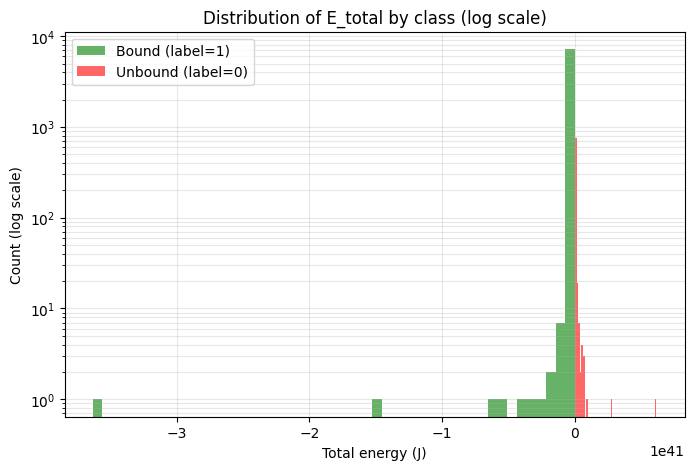

In [11]:
np.random.seed(42)
num_samples = 8000

# --- Stellar masses (solar masses → kg) ---
mass_min, mass_max = 0.5, 10.0       # range in solar masses
mass_to_kg = 1.989e30                 # conversion factor: 1 M☉ in kg
m1 = np.random.uniform(mass_min, mass_max, num_samples) * mass_to_kg
m2 = np.random.uniform(mass_min, mass_max, num_samples) * mass_to_kg

# --- Orbital separations (AU → m) ---
distance_min, distance_max = 0.1, 1000.0   # range in AU
UA_to_meters = 1.496e11                     # conversion factor: 1 AU in m
r = np.random.uniform(distance_min, distance_max, num_samples) * UA_to_meters

# --- Gravitational constant and reduced mass ---
G = 6.67430e-11                      # m³ kg⁻¹ s⁻²
m_reduced = (m1 * m2) / (m1 + m2)   # two-body reduced mass

# --- Escape (critical) velocity: v_crit = sqrt(2 G M_tot / r) ---
v_crit = np.sqrt(2 * G * (m1 + m2) / r)

# --- Imbalanced dataset: frac_bound, unbound = 1-frac_bound ---
frac_bound = 0.9
num_bound  = int(num_samples * frac_bound)
num_unbound = num_samples - num_bound

v      = np.zeros(num_samples)
labels = np.zeros(num_samples)

# Bound systems (E < 0): v drawn uniformly in [0, v_crit)
v[:num_bound] = [v_crit[i] * np.sqrt(np.random.uniform(0, 1)) for i in range(num_bound)]
labels[:num_bound] = 1

# Unbound systems (E > 0): v drawn uniformly in [v_crit, 2·v_crit)
v[num_bound:] = [v_crit[i] * (1 + np.random.uniform(0, 1)) for i in range(num_bound, num_samples)]
labels[num_bound:] = 0

# --- Total mechanical energy: E = K + U ---
K       = 0.5 * m_reduced * v**2    # kinetic energy
U       = -G * m1 * m2 / r          # gravitational potential energy
E_total = K + U

print("Bound systems:  ", np.sum(labels == 1))
print("Unbound systems:", np.sum(labels == 0))

# Energy distribution (log scale) to visualise class separation
plt.figure(figsize=(8, 5))
plt.hist(E_total[labels == 1], bins=50, color="green", alpha=0.6, label="Bound (label=1)", log=True)
plt.hist(E_total[labels == 0], bins=50, color="red",   alpha=0.6, label="Unbound (label=0)", log=True)
plt.xlabel("Total energy (J)")
plt.ylabel("Count (log scale)")
plt.title("Distribution of E_total by class (log scale)")
plt.legend()
plt.grid(True, alpha=0.3, which='both')
plt.show()


## 3. Classification Utilities

Three helper functions implement the custom threshold-based classification pipeline:

- **`TSS_function`**: computes TSS and HSS from a confusion matrix
- **`T`**: sweeps 100 thresholds τ on the training probability scores and returns the τ* maximising TSS
- **`Y_pred_test`**: applies τ* to test-set scores to produce binary predictions

**TSS** (True Skill Statistic) = TPR − FPR is preferred over accuracy for imbalanced datasets.  
**HSS** (Heidke Skill Score) measures improvement over a random classifier.

In [12]:
def TSS_function(Y_train, Y_predicted_training):
    """
    Compute TSS (True Skill Statistic) and HSS (Heidke Skill Score)
    from a confusion matrix.

    TSS = TPR - FPR  (ranges from -1 to 1; 1 = perfect, 0 = no skill)
    HSS = 2(TP·TN - FN·FP) / [(TP+FN)(FN+TN) + (TP+FP)(FP+TN)]
    """
    cm = confusion_matrix(Y_train, Y_predicted_training)
    tn, fp, fn, tp = cm.ravel()

    TSS = (tp / (tp + fn)) - (fp / (tn + fp))

    denom = (tp + fn) * (fn + tn) + (tp + fp) * (fp + tn)
    if denom == 0.0:
        HSS = 0.0 if (tp * tn - fn * fp) == 0 else -100
    else:
        HSS = 2 * (tp * tn - fn * fp) / denom

    return TSS, HSS, cm, tn, fp, fn, tp


def T(Y_train, p):
    """
    Sweep 100 probability thresholds τ ∈ [min(p), max(p)] and return
    the threshold τ* that maximises TSS on the training set.

    Returns
    -------
    taustar : float       – optimal threshold
    TSSstar : float       – TSS at τ*
    Y_predicted_training  – binary predictions at τ*
    """
    a, b     = min(p), max(p)
    n_train  = len(Y_train)
    print('a: ', a)
    print('b: ', b)

    N_tau  = 100
    delta  = (b - a) / N_tau
    TSSstar  = -1.0
    taustar  = 0.0
    tau      = np.zeros((N_tau, 1))
    TSS_list = np.zeros((N_tau, 1))

    for j in range(N_tau):
        Y_predicted_training = np.zeros((n_train, 1))
        tau[j] = a + j * delta
        Y_predicted_training[np.where(p > tau[j])] = 1.0
        TSS_list[j], HSS, cm, tn, fp, fn, tp = TSS_function(Y_train, Y_predicted_training)
        if TSS_list[j] > TSSstar:
            TSSstar = TSS_list[j]
            taustar = tau[j]

    # Apply the optimal threshold to produce the final training predictions
    Y_predicted_training = np.zeros((n_train, 1))
    Y_predicted_training[np.where(p > taustar)] = 1.0

    return taustar, TSSstar, Y_predicted_training


def Y_pred_test(ptest, taustar):
    """
    Apply a fixed threshold τ* to test-set probability scores.
    Samples with p > τ* are predicted as class 1, otherwise class 0.
    """
    Y_predicted_test = np.zeros((len(ptest), 1))
    Y_predicted_test[np.where(ptest > taustar)] = 1.0
    return Y_predicted_test


## 4. Standard Features (SFs) – Preprocessing

Features: m₁, m₂, r, v, G (raw physical quantities).  
Two targets are prepared in parallel:
- `Y_feat` — binary class label (bound / unbound) for classification
- `Y_feat_alt` — continuous E_total (J) for regression, scaled with `StandardScaler`

Data is split 80/20 and features are standardized (zero mean, unit variance).

In [13]:
# --- Standard Features (SFs) dataframe ---
# Raw physical quantities: m1, m2, r, v, G
data_feat = pd.DataFrame({
    'm1 (kg)': m1,
    'm2 (kg)': m2,
    'r (m)': r,
    'v (m/s)': v,
    'G (m^3 * kg^-1 * s^-2)': G,
    'Label': labels,
    'E_total (J)': E_total
})

df_feat = pd.DataFrame(data_feat)
print(df_feat.head())

# Separate features (X), binary label (Y), and regression target (Y_alt = E_total)
X_feat     = df_feat.drop(columns=['Label', 'E_total (J)'])
Y_feat     = df_feat['Label']
Y_feat_alt = df_feat['E_total (J)']

# 80/20 train-test split; both label types are split together to keep alignment
X_train_feat, X_test_feat, Y_train_feat, Y_test_feat, Y_train_feat_2, Y_test_feat_2 = train_test_split(
    X_feat, Y_feat, Y_feat_alt, test_size=0.2, random_state=42
)

# Standardize features (zero mean, unit variance)
scaler_X = StandardScaler()
X_train_feat_scaled = scaler_X.fit_transform(X_train_feat)
X_test_feat_scaled  = scaler_X.transform(X_test_feat)

# Standardize regression target (E_total)
scaler_Y = StandardScaler()
Y_train_feat_scaled = scaler_Y.fit_transform(Y_train_feat_2.values.reshape(-1, 1))
Y_test_feat_scaled  = scaler_Y.transform(Y_test_feat_2.values.reshape(-1, 1))

print(f"TRAIN classification labels: {Y_train_feat.shape}")
print(f"TRAIN regression labels (scaled): {Y_train_feat_scaled.shape}")
print(f"TEST classification labels: {Y_test_feat.shape}")
print(f"TEST regression labels (scaled): {Y_test_feat_scaled.shape}")


        m1 (kg)       m2 (kg)         r (m)        v (m/s)  \
0  8.071623e+30  1.460432e+31  6.733749e+11   55511.724061   
1  1.895872e+31  1.398106e+31  6.434689e+10  178746.766215   
2  1.482589e+31  2.803823e+30  7.065851e+13    1362.111786   
3  1.230645e+31  1.842697e+31  4.396860e+12   29274.801064   
4  3.942550e+30  1.173607e+31  1.457905e+14    3751.398030   

   G (m^3 * kg^-1 * s^-2)  Label   E_total (J)  
0            6.674300e-11    1.0 -3.674287e+39  
1            6.674300e-11    1.0 -1.463824e+41  
2            6.674300e-11    1.0 -3.707828e+37  
3            6.674300e-11    1.0 -2.805132e+38  
4            6.674300e-11    1.0 -4.166774e+35  
TRAIN classification labels: (6400,)
TRAIN regression labels (scaled): (6400, 1)
TEST classification labels: (1600,)
TEST regression labels (scaled): (1600, 1)


### 4.1 SVC (Linear Kernel) on Standard Features

`SVC` with `probability=True` outputs calibrated class probabilities.  
The custom `T()` function sweeps 100 thresholds on the training scores to find the τ* that maximises TSS, then applies it to the test set.

In [14]:
# --- SVC (linear kernel) on Standard Features ---
# probability=True enables predict_proba(), required by the T() threshold sweep
svc = SVC(probability=True)

param_grid = {
    'C':      [1.0],
    'kernel': ['linear'],
}

grid_search = GridSearchCV(
    estimator=svc,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    verbose=1
)
grid_search.fit(X_train_feat_scaled, Y_train_feat)

best_svc_model = grid_search.best_estimator_
print(f"Best parameters: {grid_search.best_params_}")

# Obtain class-1 probability scores on the training set
p_train = best_svc_model.predict_proba(X_train_feat_scaled)[:, 1]

# Find the optimal threshold τ* that maximises TSS on training data
taustar, TSS_star, Y_predicted_training = T(Y_train_feat, p_train)
print(taustar)
TSS_train, HSS_train, cm_train, tn_train, fp_train, fn_train, tp_train = TSS_function(Y_train_feat, Y_predicted_training)

# Apply τ* to the test set
p_test = best_svc_model.predict_proba(X_test_feat_scaled)[:, 1]
Y_predicted_test = Y_pred_test(p_test, taustar)

TSS_test, HSS_test, cm_test, tn_test, fp_test, fn_test, tp_test = TSS_function(Y_test_feat, Y_predicted_test)

print(f"TSS TRAIN: {TSS_train}")
print(f"TSS TEST:  {TSS_test}")
print(f"HSS TRAIN: {HSS_train}")
print(f"HSS TEST:  {HSS_test}")

print(f"Confusion matrix TEST:\n{cm_test}")

# Extract confusion matrix entries for per-metric reporting
TN = cm_test[0, 0]
FP = cm_test[0, 1]
FN = cm_test[1, 0]
TP = cm_test[1, 1]

specificity = TN / (TN + FP)
sensitivity = TP / (TP + FN)
accuracy    = (TP + TN) / (TP + TN + FP + FN)

print(f"Specificity: {specificity}")
print(f"Sensitivity: {sensitivity}")
print(f"Accuracy:    {accuracy}")


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best parameters: {'C': 1.0, 'kernel': 'linear'}
a:  4.3244927762590136e-05
b:  0.9845410774172916
[0.92547121]
TSS TRAIN: 0.3936784687483431
TSS TEST:  0.3475657929387805
HSS TRAIN: 0.15292905087238598
HSS TEST:  0.13541317537295566
Confusion matrix TEST:
[[120  38]
 [594 848]]
Specificity: 0.759493670886076
Sensitivity: 0.5880721220527045
Accuracy:    0.605


### 4.2 SVC (RBF Kernel) on Standard Features

Same pipeline as above with a Gaussian (RBF) kernel, which can capture non-linear boundaries in the feature space.

In [15]:
# --- SVC (rbf kernel) on Standard Features ---
# probability=True enables predict_proba(), required by the T() threshold sweep
svc = SVC(probability=True)

param_grid = {
    'C':      [1.0],
    'kernel': ['rbf'],
}

grid_search = GridSearchCV(
    estimator=svc,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    verbose=1
)
grid_search.fit(X_train_feat_scaled, Y_train_feat)

best_svc_model = grid_search.best_estimator_
print(f"Best parameters: {grid_search.best_params_}")

# Obtain class-1 probability scores on the training set
p_train = best_svc_model.predict_proba(X_train_feat_scaled)[:, 1]

# Find the optimal threshold τ* that maximises TSS on training data
taustar, TSS_star, Y_predicted_training = T(Y_train_feat, p_train)
print(taustar)
TSS_train, HSS_train, cm_train, tn_train, fp_train, fn_train, tp_train = TSS_function(Y_train_feat, Y_predicted_training)

# Apply τ* to the test set
p_test = best_svc_model.predict_proba(X_test_feat_scaled)[:, 1]
Y_predicted_test = Y_pred_test(p_test, taustar)

TSS_test, HSS_test, cm_test, tn_test, fp_test, fn_test, tp_test = TSS_function(Y_test_feat, Y_predicted_test)

print(f"TSS TRAIN: {TSS_train}")
print(f"TSS TEST:  {TSS_test}")
print(f"HSS TRAIN: {HSS_train}")
print(f"HSS TEST:  {HSS_test}")

print(f"Confusion matrix TEST:\n{cm_test}")

# Extract confusion matrix entries for per-metric reporting
TN = cm_test[0, 0]
FP = cm_test[0, 1]
FN = cm_test[1, 0]
TP = cm_test[1, 1]

specificity = TN / (TN + FP)
sensitivity = TP / (TP + FN)
accuracy    = (TP + TN) / (TP + TN + FP + FN)

print(f"Specificity: {specificity}")
print(f"Sensitivity: {sensitivity}")
print(f"Accuracy:    {accuracy}")


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best parameters: {'C': 1.0, 'kernel': 'rbf'}
a:  1.0000000994736041e-07
b:  0.9999999999999699
[0.88000001]
TSS TRAIN: 0.9849230489558615
TSS TEST:  0.9769395530118156
HSS TRAIN: 0.9668587689625998
HSS TEST:  0.9424172883623646
Confusion matrix TEST:
[[ 156    2]
 [  15 1427]]
Specificity: 0.9873417721518988
Sensitivity: 0.9895977808599168
Accuracy:    0.989375


## 5. Physics-Informed Features (SPIFs) – Preprocessing

Features: K = μv² and U = −Gm₁m₂/r — the two energy components whose sum directly determines the classification label (sign of E_total).  
Same 80/20 split and standardization as the SF pipeline.

In [16]:
# --- Physics-Informed Features (SPIFs) dataframe ---
# Derived energy quantities that directly encode the classification boundary
data_op = pd.DataFrame({
    'K': m_reduced * v**2,   # twice the kinetic energy (ρ v²)
    'U': U,                   # gravitational potential energy (-G m1 m2 / r)
    'Label': labels,
    'E_total (J)': E_total
})

df_op = pd.DataFrame(data_op)
print(df_op.head())

# Separate features (X), binary label (Y), and regression target (Y_alt = E_total)
X_op     = df_op.drop(columns=['Label', 'E_total (J)'])
Y_op     = df_op['Label']
Y_op_alt = df_op['E_total (J)']

# 80/20 train-test split; both label types are split together to keep alignment
X_train_op, X_test_op, Y_train_op, Y_test_op, Y_train_op_2, Y_test_op_2 = train_test_split(
    X_op, Y_op, Y_op_alt, test_size=0.2, random_state=42
)

# Standardize features
scaler_X = StandardScaler()
X_train_op_scaled = scaler_X.fit_transform(X_train_op)
X_test_op_scaled  = scaler_X.transform(X_test_op)

# Standardize regression target (E_total)
scaler_Y = StandardScaler()
Y_train_op_scaled = scaler_Y.fit_transform(Y_train_op_2.values.reshape(-1, 1))
Y_test_op_scaled  = scaler_Y.transform(Y_test_op_2.values.reshape(-1, 1))

print(f"TRAIN classification labels: {Y_train_op.shape}")
print(f"TRAIN regression labels (scaled): {Y_train_op_scaled.shape}")
print(f"TEST classification labels: {Y_test_op.shape}")
print(f"TEST regression labels (scaled): {Y_test_op_scaled.shape}")


              K             U  Label   E_total (J)
0  1.601940e+40 -1.168399e+40    1.0 -3.674287e+39
1  2.571016e+41 -2.749332e+41    1.0 -1.463824e+41
2  4.374734e+36 -3.926565e+37    1.0 -3.707828e+37
3  6.323590e+39 -3.442308e+39    1.0 -2.805132e+38
4  4.153157e+37 -2.118246e+37    1.0 -4.166774e+35
TRAIN classification labels: (6400,)
TRAIN regression labels (scaled): (6400, 1)
TEST classification labels: (1600,)
TEST regression labels (scaled): (1600, 1)


### 5.1 SVC (Linear Kernel) on Physics-Informed Features

With C=10000 (minimal regularization), the linear SVC on (K, U) is expected to recover the exact boundary E = K + U = 0.

In [17]:
# --- SVC (linear kernel) on Physics-Informed Features ---
# probability=True enables predict_proba(), required by the T() threshold sweep
svc = SVC(probability=True)

param_grid = {
    'C':      [10000.0],
    'kernel': ['linear'],
}

grid_search = GridSearchCV(
    estimator=svc,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    verbose=1
)
grid_search.fit(X_train_op_scaled, Y_train_op)

best_svc_model = grid_search.best_estimator_
print(f"Best parameters: {grid_search.best_params_}")

# Obtain class-1 probability scores on the training set
p_train = best_svc_model.predict_proba(X_train_op_scaled)[:, 1]

# Find the optimal threshold τ* that maximises TSS on training data
taustar, TSS_star, Y_predicted_training = T(Y_train_op, p_train)
print(taustar)
TSS_train, HSS_train, cm_train, tn_train, fp_train, fn_train, tp_train = TSS_function(Y_train_op, Y_predicted_training)

# Apply τ* to the test set
p_test = best_svc_model.predict_proba(X_test_op_scaled)[:, 1]
Y_predicted_test = Y_pred_test(p_test, taustar)

TSS_test, HSS_test, cm_test, tn_test, fp_test, fn_test, tp_test = TSS_function(Y_test_op, Y_predicted_test)

print(f"TSS TRAIN: {TSS_train}")
print(f"TSS TEST:  {TSS_test}")
print(f"HSS TRAIN: {HSS_train}")
print(f"HSS TEST:  {HSS_test}")

print(f"Confusion matrix TEST:\n{cm_test}")

# Extract confusion matrix entries for per-metric reporting
TN = cm_test[0, 0]
FP = cm_test[0, 1]
FN = cm_test[1, 0]
TP = cm_test[1, 1]

specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
accuracy    = (TP + TN) / (TP + TN + FP + FN)

print(f"Specificity: {specificity}")
print(f"Sensitivity: {sensitivity}")
print(f"Accuracy:    {accuracy}")


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best parameters: {'C': 10000.0, 'kernel': 'linear'}
a:  1.0000000994736041e-07
b:  0.9999999999999699
[0.88000001]
TSS TRAIN: 0.9984423676012462
TSS TEST:  0.9936708860759493
HSS TRAIN: 0.9991337486647548
HSS TEST:  0.9964787802494784
Confusion matrix TEST:
[[ 157    1]
 [   0 1442]]
Specificity: 0.9936708860759493
Sensitivity: 1.0
Accuracy:    0.999375


### 5.2 SVC (RBF Kernel) on Physics-Informed Features

RBF kernel variant on the two energy features.

In [18]:
# --- SVC (rbf kernel) on Physics-Informed Features ---
# probability=True enables predict_proba(), required by the T() threshold sweep
svc = SVC(probability=True)

param_grid = {
    'C':      [10000.0],
    'kernel': ['rbf'],
}

grid_search = GridSearchCV(
    estimator=svc,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    verbose=1
)
grid_search.fit(X_train_op_scaled, Y_train_op)

best_svc_model = grid_search.best_estimator_
print(f"Best parameters: {grid_search.best_params_}")

# Obtain class-1 probability scores on the training set
p_train = best_svc_model.predict_proba(X_train_op_scaled)[:, 1]

# Find the optimal threshold τ* that maximises TSS on training data
taustar, TSS_star, Y_predicted_training = T(Y_train_op, p_train)
print(taustar)
TSS_train, HSS_train, cm_train, tn_train, fp_train, fn_train, tp_train = TSS_function(Y_train_op, Y_predicted_training)

# Apply τ* to the test set
p_test = best_svc_model.predict_proba(X_test_op_scaled)[:, 1]
Y_predicted_test = Y_pred_test(p_test, taustar)

TSS_test, HSS_test, cm_test, tn_test, fp_test, fn_test, tp_test = TSS_function(Y_test_op, Y_predicted_test)

print(f"TSS TRAIN: {TSS_train}")
print(f"TSS TEST:  {TSS_test}")
print(f"HSS TRAIN: {HSS_train}")
print(f"HSS TEST:  {HSS_test}")

print(f"Confusion matrix TEST:\n{cm_test}")

# Extract confusion matrix entries for per-metric reporting
TN = cm_test[0, 0]
FP = cm_test[0, 1]
FN = cm_test[1, 0]
TP = cm_test[1, 1]

specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
accuracy    = (TP + TN) / (TP + TN + FP + FN)

print(f"Specificity: {specificity}")
print(f"Sensitivity: {sensitivity}")
print(f"Accuracy:    {accuracy}")


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best parameters: {'C': 10000.0, 'kernel': 'rbf'}
a:  1.0000000994736041e-07
b:  0.9999999999999699
[0.88000001]
TSS TRAIN: 1.0
TSS TEST:  0.9929774047999438
HSS TRAIN: 1.0
HSS TEST:  0.9929774047999438
Confusion matrix TEST:
[[ 157    1]
 [   1 1441]]
Specificity: 0.9936708860759493
Sensitivity: 0.9993065187239945
Accuracy:    0.99875
